Loading data...
Starting path computation...
Lasso without screening - time: 0.16 s
Lasso with screening    - time: 0.10 s
Celer                   - time: 0.02 s
Lasso without screening - time: 1.61 s
Lasso with screening    - time: 0.51 s
Celer                   - time: 0.08 s
Lasso without screening - time: 9.39 s
Lasso with screening    - time: 2.23 s
Celer                   - time: 0.20 s


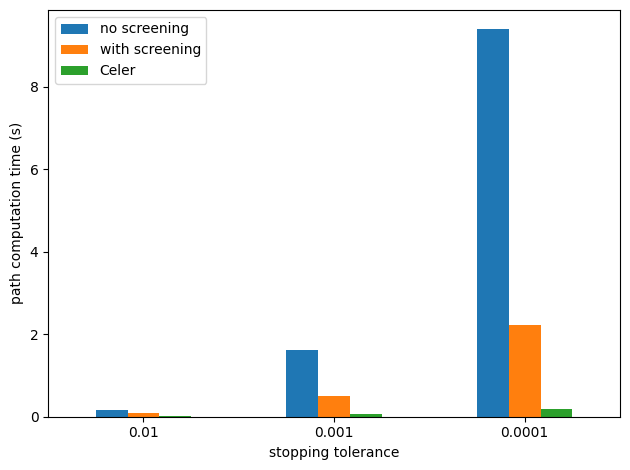

In [3]:
# https://github.com/mathurinm/celer/blob/main/examples/plot_leukemia_path.py
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import lasso_path
from sklearn.datasets import fetch_openml

from celer import celer_path


print("Loading data...")
dataset = fetch_openml(data_id=1104)  # "leukemia"
X = np.asfortranarray(dataset.data.astype(float))
y = 2 * ((dataset.target != "AML") - 0.5)
n_samples = len(y)

y -= np.mean(y)
y /= np.std(y)

print("Starting path computation...")
alpha_max = np.max(np.abs(X.T.dot(y))) / n_samples

n_alphas = 100
alphas = alpha_max * np.geomspace(1, 0.01, n_alphas)

tols = [1e-2, 1e-3, 1e-4]
results = np.zeros([3, len(tols)])
for tol_ix, tol in enumerate(tols):
    t0 = time.time()
    _, coefs, gaps = lasso_path(
        X, y, alphas=alphas, tol=tol, max_iter=10_000, do_screening=False)
    results[0, tol_ix] = time.time() - t0
    print('Lasso without screening - time: %.2f s' % results[0, tol_ix])

    t0 = time.time()
    _, coefs, dual_gaps = lasso_path(
        X, y, alphas=alphas, tol=tol, max_iter=10_000, do_screening=True)
    results[1, tol_ix] = time.time() - t0
    print('Lasso with screening    - time: %.2f s' % results[1, tol_ix])

    t0 = time.time()
    _, coefs, dual_gaps = celer_path(
        X, y, pb="lasso", alphas=alphas, tol=tol, max_iter=10_000, prune=True)
    results[2, tol_ix] = time.time() - t0
    print('Celer                   - time: %.2f s' % results[2, tol_ix])

df = pd.DataFrame(results.T, columns=["no screening", "with screening", "Celer"])
df.index = [str(tol) for tol in tols]
df.plot.bar(rot=0)
plt.xlabel("stopping tolerance")
plt.ylabel("path computation time (s)")
plt.tight_layout()
plt.show()

In [3]:
X.shape

(72, 7129)

In [4]:
# For single values of alpha
import time
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.linear_model import lasso_path
from sklearn.datasets import fetch_openml

from celer import celer_path


print("Loading data...")
dataset = fetch_openml(data_id=1104)  # "leukemia"
X = np.asfortranarray(dataset.data.astype(float))
y = 2 * ((dataset.target != "AML") - 0.5)
n_samples = len(y)

y -= np.mean(y)
y /= np.std(y)

print("Starting path computation...")
alpha_max = np.max(np.abs(X.T.dot(y))) / n_samples

n_alphas = 1

tols = [1e-2, 1e-3, 1e-4]
results = []  # scale_alpha_max, tol, solver, time
penalty_scales = [1e-1, 1e-2, 1e-5]

for alpha_idx, scale_alpha_max in enumerate(penalty_scales):
    alpha = [alpha_max * scale_alpha_max]
    print(f"alpha = alpha_max * {scale_alpha_max}")
    for tol_ix, tol in enumerate(tols):
        t0 = time.time()
        _, coefs, gaps = lasso_path(
            X, y, alphas=alpha, tol=tol, max_iter=10_000, do_screening=False)
        t = time.time() - t0
        results += [[scale_alpha_max, tol, "no_screening", t]] 
        print('  Lasso without screening - time: %.2f s' % t)

        t0 = time.time()
        _, coefs, dual_gaps = lasso_path(
            X, y, alphas=alpha, tol=tol, max_iter=10_000, do_screening=True)
        t = time.time() - t0
        results += [[scale_alpha_max, tol, "with_screening", t]] 
        print('  Lasso with screening    - time: %.2f s' % t)

        t0 = time.time()
        _, coefs, dual_gaps = celer_path(
            X, y, pb="lasso", alphas=alpha, tol=tol, max_iter=10_000, prune=True)
        t = time.time() - t0
        results += [[scale_alpha_max, tol, "Celer", t]] 
        print('  Lasso with Celer   - time: %.2f s' % t)

Loading data...
Starting path computation...
alpha = alpha_max * 0.1
  Lasso without screening - time: 0.01 s
  Lasso with screening    - time: 0.00 s
  Lasso with Celer   - time: 0.00 s
  Lasso without screening - time: 0.03 s
  Lasso with screening    - time: 0.01 s
  Lasso with Celer   - time: 0.00 s
  Lasso without screening - time: 0.03 s
  Lasso with screening    - time: 0.01 s
  Lasso with Celer   - time: 0.00 s
alpha = alpha_max * 0.01
  Lasso without screening - time: 0.02 s
  Lasso with screening    - time: 0.02 s
  Lasso with Celer   - time: 0.02 s
  Lasso without screening - time: 0.88 s
  Lasso with screening    - time: 0.48 s
  Lasso with Celer   - time: 0.03 s
  Lasso without screening - time: 1.80 s
  Lasso with screening    - time: 0.88 s
  Lasso with Celer   - time: 0.06 s
alpha = alpha_max * 1e-05
  Lasso without screening - time: 0.00 s
  Lasso with screening    - time: 0.00 s
  Lasso with Celer   - time: 0.05 s
  Lasso without screening - time: 0.49 s
  Lasso with 

In [5]:
df = pd.DataFrame(
    results,
    columns=["scale_alpha_max", "tol", "solver", "time [s]"],
)
df

,scale_alpha_max,tol,solver,time [s]
0,0.10000,0.0100,no_screening,0.009164
1,0.10000,0.0100,with_screening,0.004364
2,0.10000,0.0100,Celer,0.002412
3,0.10000,0.0010,no_screening,0.026031
4,0.10000,0.0010,with_screening,0.009252
5,0.10000,0.0010,Celer,0.002857
6,0.10000,0.0001,no_screening,0.032673
7,0.10000,0.0001,with_screening,0.012131
8,0.10000,0.0001,Celer,0.003142
9,0.01000,0.0100,no_screening,0.020457


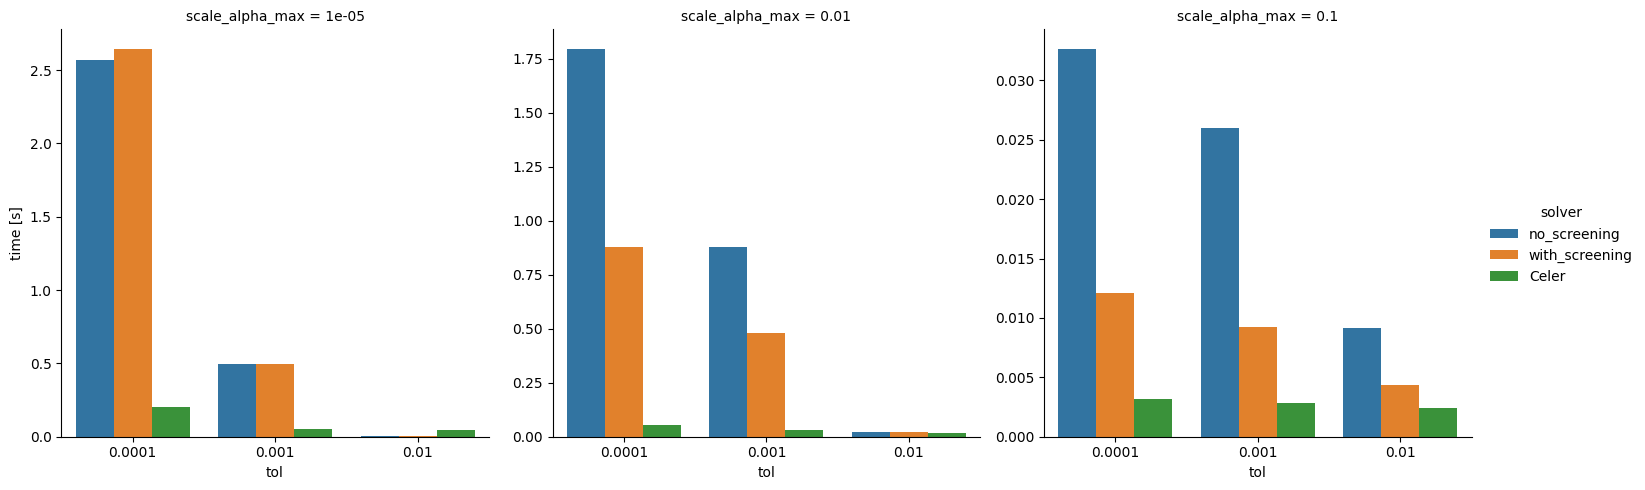

In [6]:
sns.catplot(
    df, x="tol", y="time [s]", hue="solver", col="scale_alpha_max", kind="bar", errorbar=None, sharey=False
)